1: packages
2: Feature Comparison
3: Mapping
4: New feature USFS region ** (May not be allowed, but can use lat/lon in a nonlinear model)
5: Logistic Regression
6: Trees
7: SVM
8: Neural Net

*Side Quest: Fire weather forecast/conditions PCA

In [13]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

#model packages
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, TunedThresholdClassifierCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, f1_score



import sys
!{sys.executable} -m pip install xgboost
import xgboost as xgb
! pip install shap
import shap
shap.initjs()


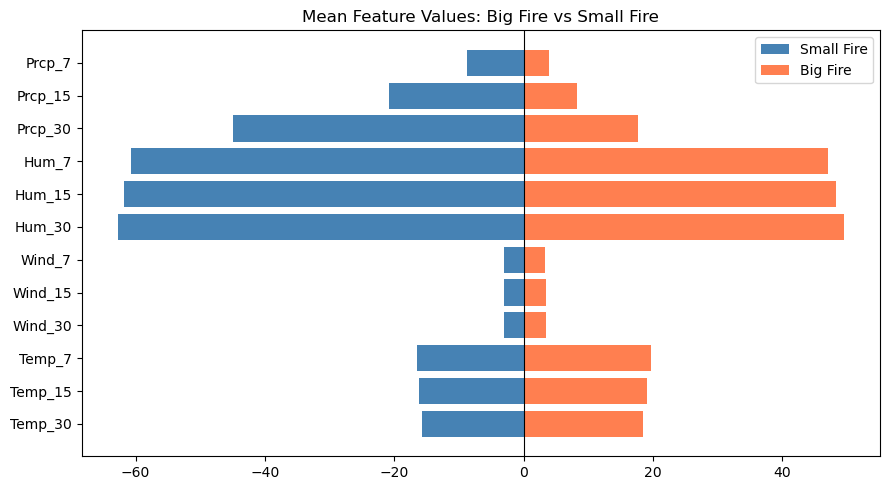

In [14]:
ff_df = pd.read_csv('forest_fires_train.csv')


#Visualize different in means
means = ff_df.groupby(['big_fire']).mean()

means = means.drop(columns=['lat', 'long', 'dist_met_station'])

categories = means.columns
group0 = means.loc[0]   # goes LEFT (negative)
group1 = means.loc[1]  # goes RIGHT (positive)

y = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(y, -group0, label='Small Fire', color='steelblue')
ax.barh(y,  group1, label='Big Fire', color='coral')

ax.set_yticks(y)
ax.set_yticklabels(categories)
ax.axvline(0, color='black', linewidth=0.8)
ax.legend()
ax.set_title('Mean Feature Values: Big Fire vs Small Fire')
plt.tight_layout()
plt.show()

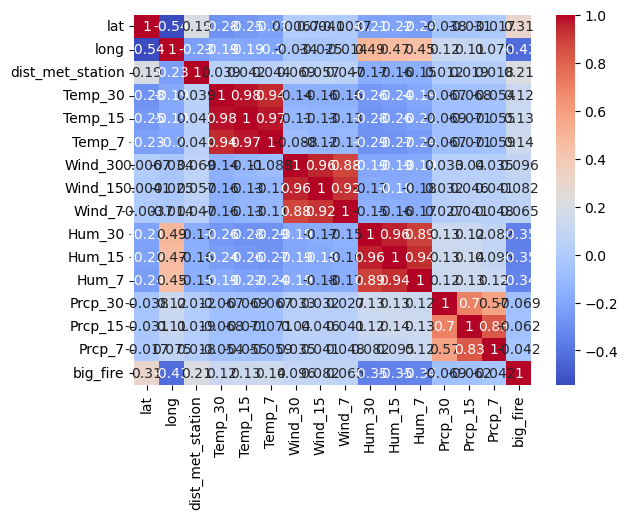

In [4]:
#heatmap
sns.heatmap(ff_df.corr(), annot=True, cmap='coolwarm')
plt.show()

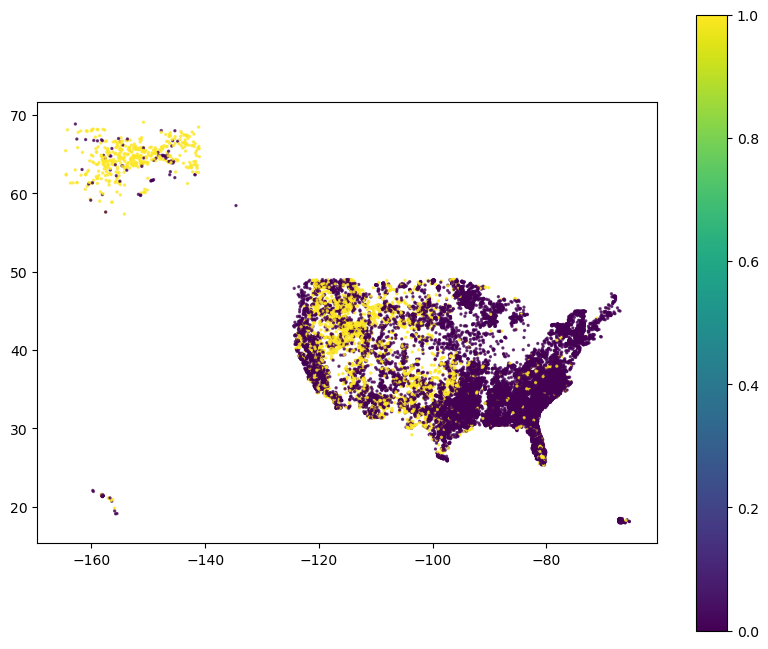

In [4]:
gdf = gpd.GeoDataFrame(ff_df,
                       geometry=gpd.points_from_xy(ff_df['long'], ff_df['lat']),
                       crs=4326)

# Create the figure and ax
fig, ax = plt.subplots(figsize=(10, 8))

# Plot your points on top
gdf.plot(
    ax=ax,
    column='big_fire',
    markersize=2,
    alpha=0.7,
    legend=True
)

plt.show()

Might be worth doing with a mean of the 7, 15, 30 days

In [41]:
ff_df.columns

Index(['lat', 'long', 'dist_met_station', 'Temp_30', 'Temp_15', 'Temp_7',
       'Wind_30', 'Wind_15', 'Wind_7', 'Hum_30', 'Hum_15', 'Hum_7', 'Prcp_30',
       'Prcp_15', 'Prcp_7', 'big_fire'],
      dtype='object')

In [17]:
#with Array
ff_arr = ff_df.drop(columns='big_fire').values
size_arr = ff_df['big_fire'].values


ff_train, ff_test, size_train, size_test = train_test_split(ff_arr, size_arr, random_state=1, stratify=size_arr)

#with DF
X = ff_df.drop(columns='big_fire')
y = ff_df['big_fire']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)


              precision    recall  f1-score   support

           0       0.93      0.84      0.88      4162
           1       0.44      0.67      0.53       766

    accuracy                           0.81      4928
   macro avg       0.68      0.75      0.71      4928
weighted avg       0.85      0.81      0.83      4928

0.823172606060302
0.5274043433298863
0.6120740124051377


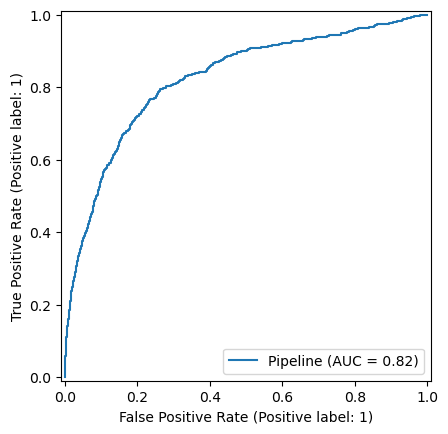

In [12]:
#logistic regression
#Pipeline
pipe = make_pipeline(
    StandardScaler(),
    TunedThresholdClassifierCV(LogisticRegression(class_weight='balanced'), scoring='f1', cv=5),
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]))
print(f1_score(y_test, y_pred))
print(pipe.named_steps['tunedthresholdclassifiercv'].best_threshold_)

RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.show()

Best Paramaters {'classifier__colsample_bytree': 0.7, 'classifier__gamma': 5, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 500, 'classifier__subsample': 0.7}
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      4162
           1       0.51      0.71      0.59       766

    accuracy                           0.85      4928
   macro avg       0.73      0.79      0.75      4928
weighted avg       0.87      0.85      0.86      4928

0.8732724777076696



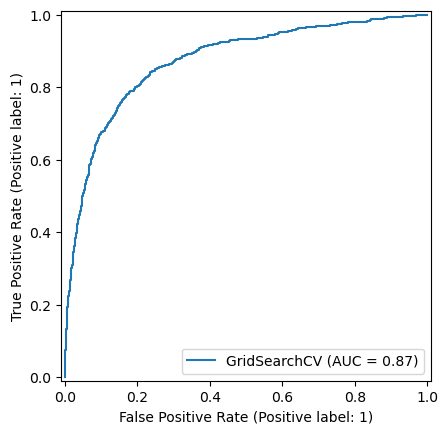

In [ ]:
#Boosted Forest
scale = sum(y_train==0)/sum(y_train==1)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=scale))
])

scale = sum(y_train==0)/sum(y_train==1)

param_grid = {
    'classifier__n_estimators': [100, 500],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.7, 1.0],
    'classifier__colsample_bytree': [0.7, 1.0],
    'classifier__gamma': [0, 1, 5]
}


grid = GridSearchCV(pipe, param_grid=param_grid, scoring='f1', n_jobs=-1, cv=5)


grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
print(f'Best Paramaters {grid.best_params_}')
#Best Paramaters {'classifier__colsample_bytree': 0.7, 'classifier__gamma': 5, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 500, 'classifier__subsample': 0.7}

print(classification_report(y_test, y_pred))

RocCurveDisplay.from_estimator(grid, X_test, y_test)
plt.show()



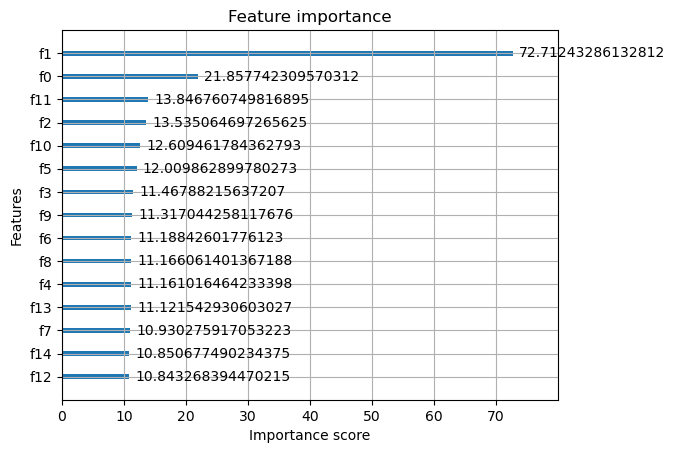

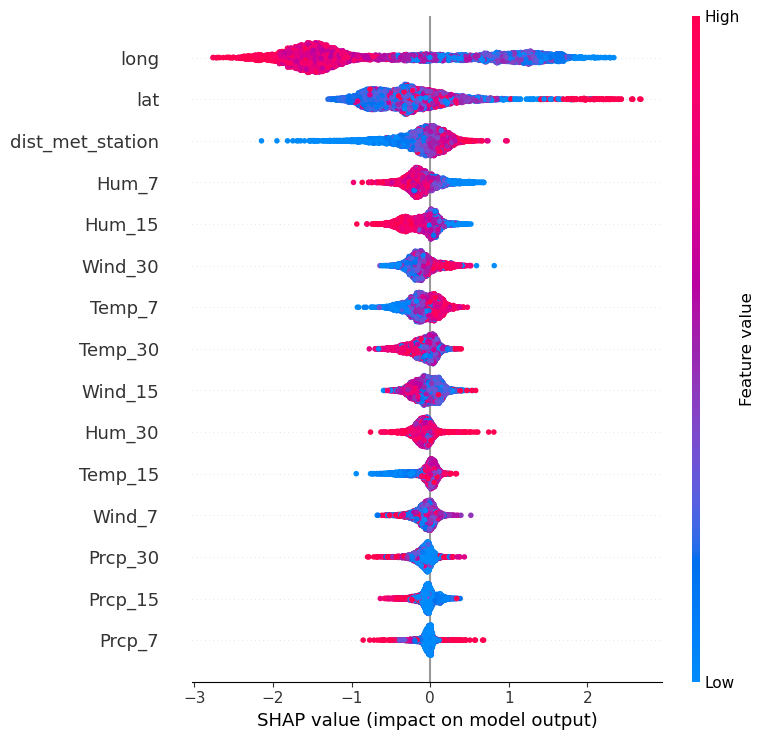

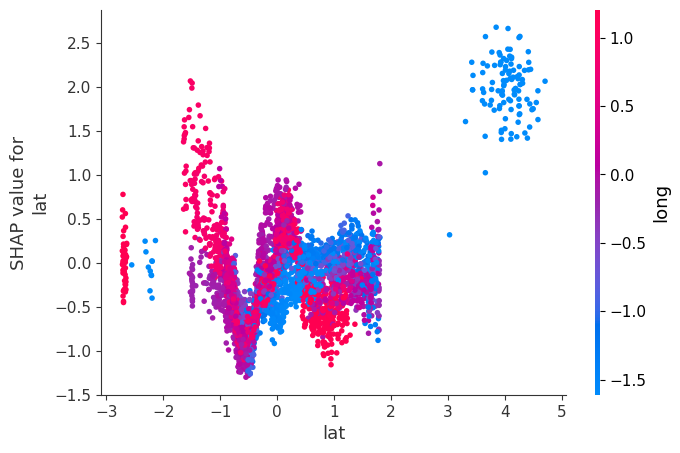

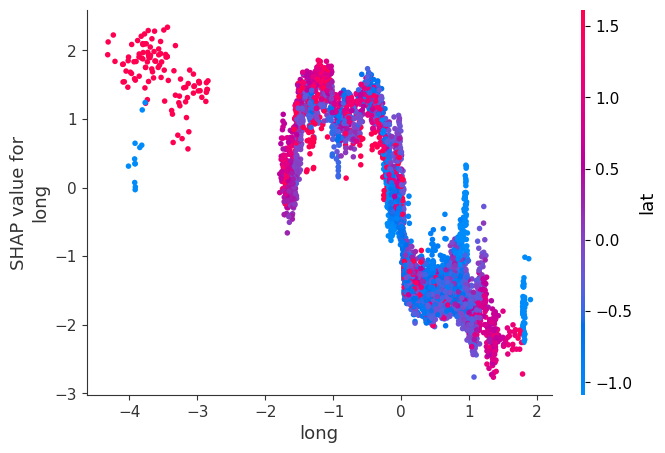

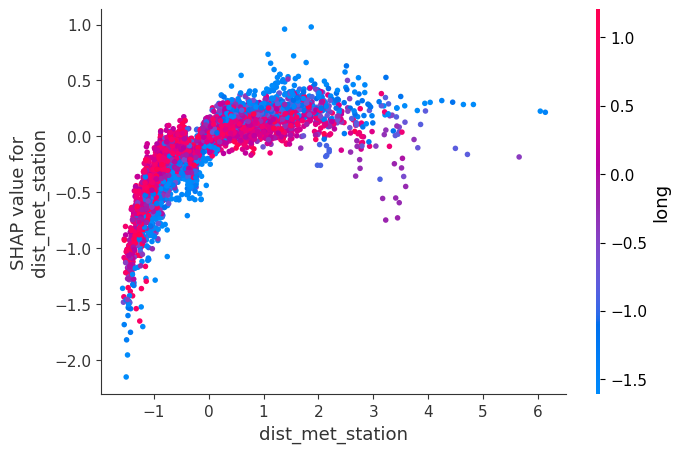

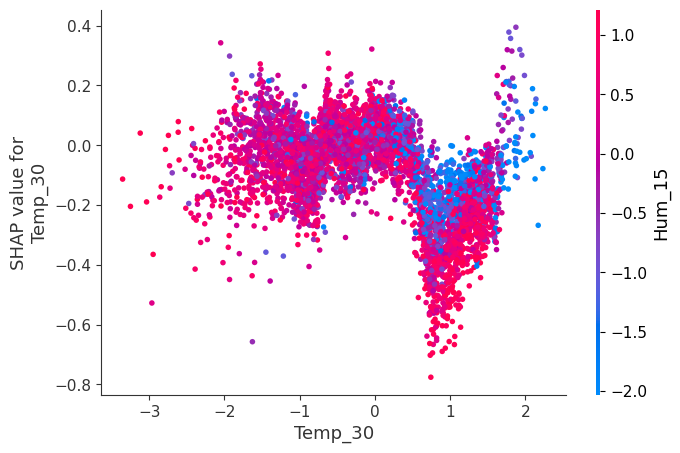

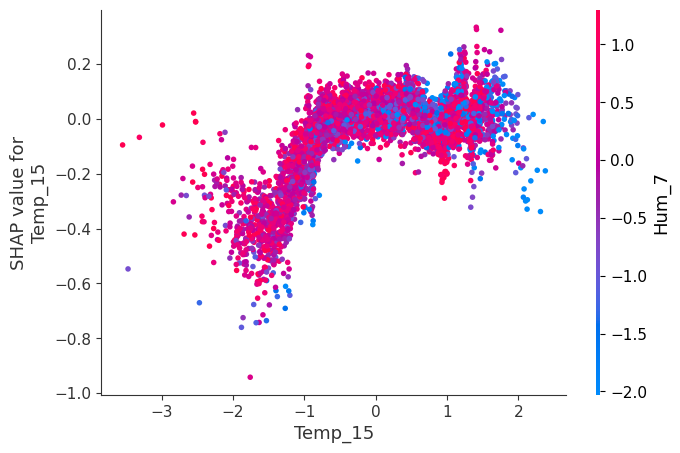

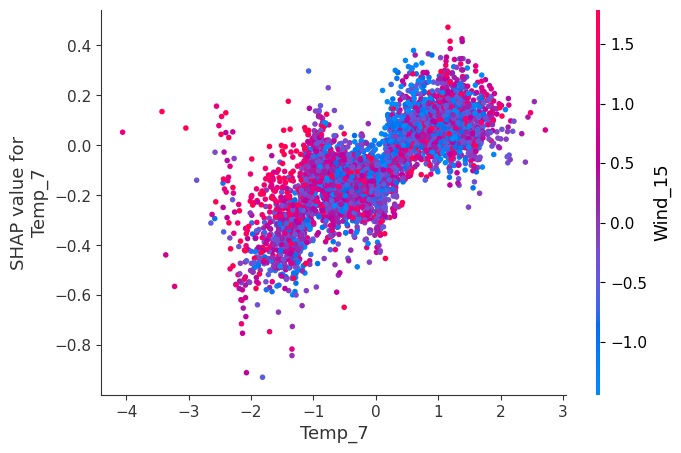

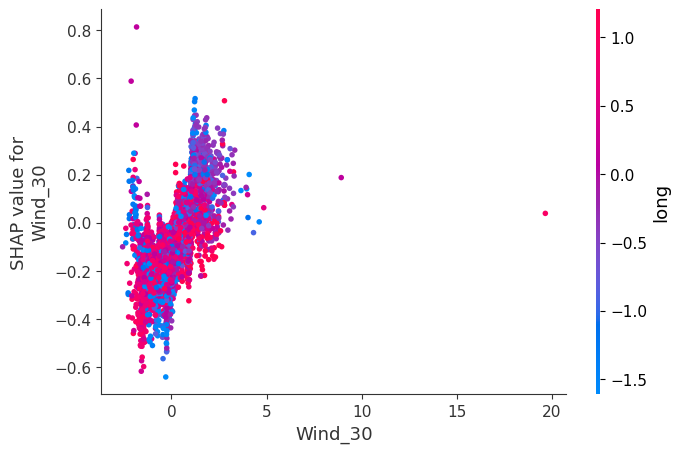

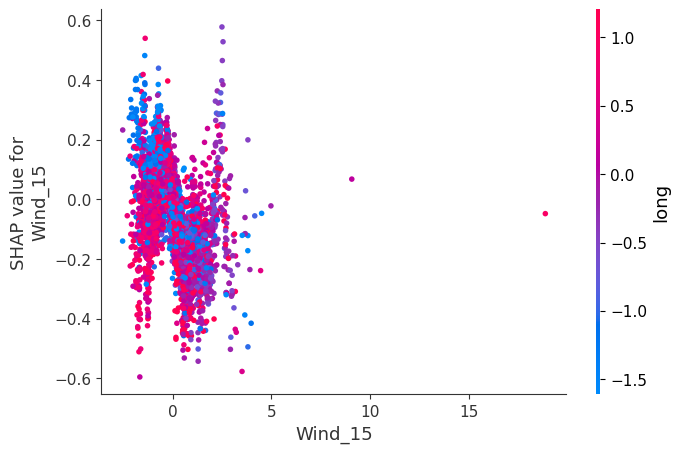

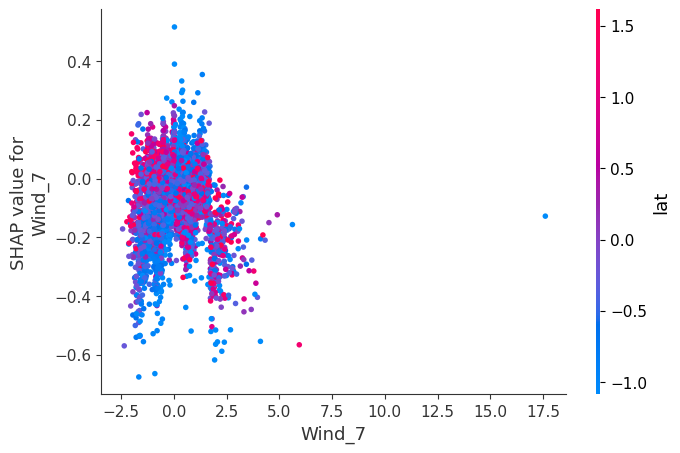

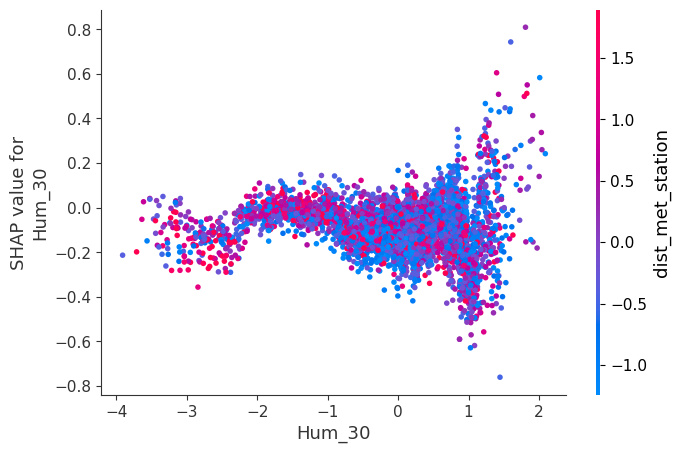

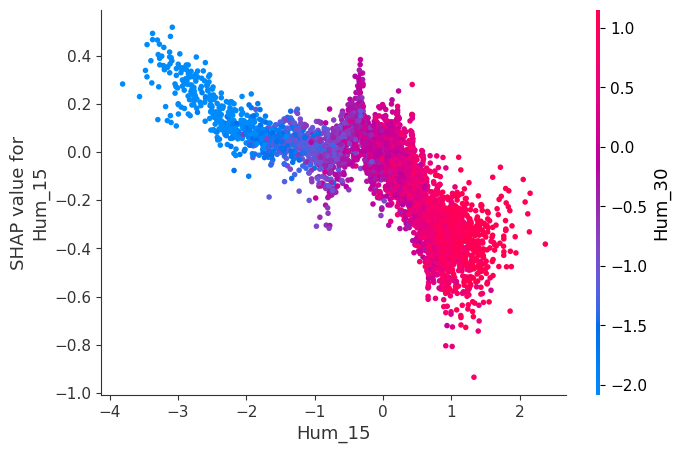

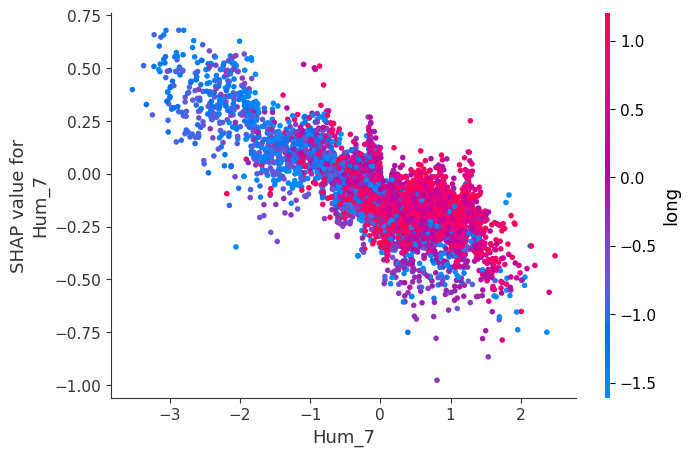

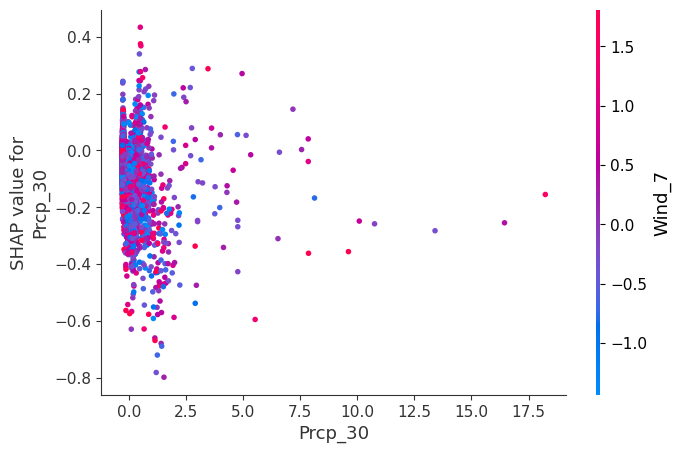

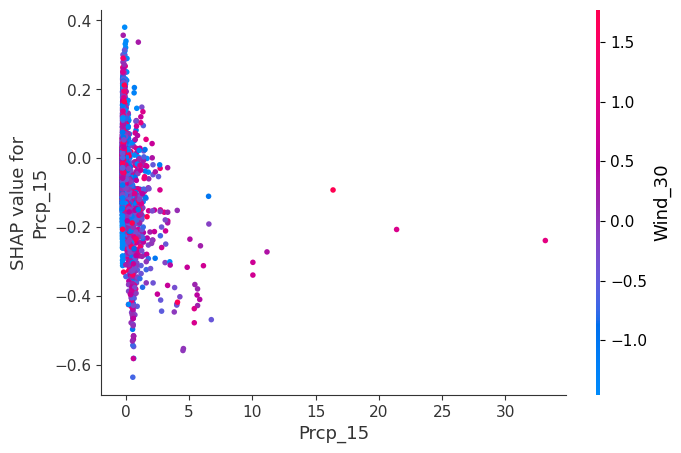

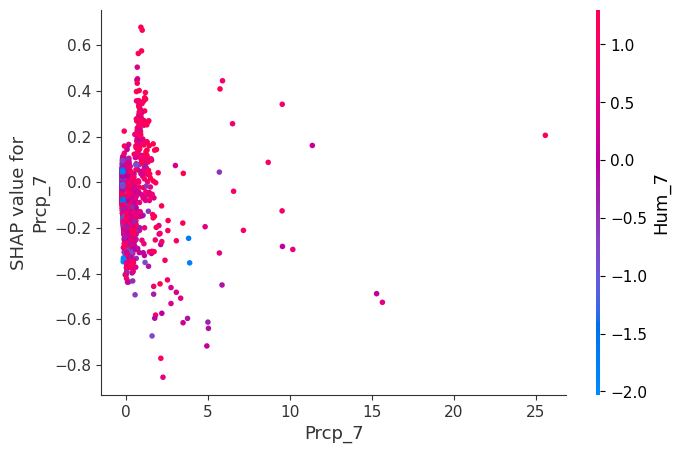

In [11]:
#xgboost BUilt in
xgb.plot_importance(grid.best_estimator_.named_steps['classifier'], importance_type='gain')

plt.show()

#shap_values
X_test_scaled = grid.best_estimator_.named_steps['scaler'].transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

explainer = shap.TreeExplainer(grid.best_estimator_.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_scaled)

shap.force_plot(explainer.expected_value, shap_values[:100,:], X_test_scaled.iloc[:100,:])

shap.summary_plot(shap_values, X_test_scaled)

for ft in X_test_scaled.columns:
    shap.dependence_plot(ft, shap_values, X_test_scaled, display_features=X_test_scaled)




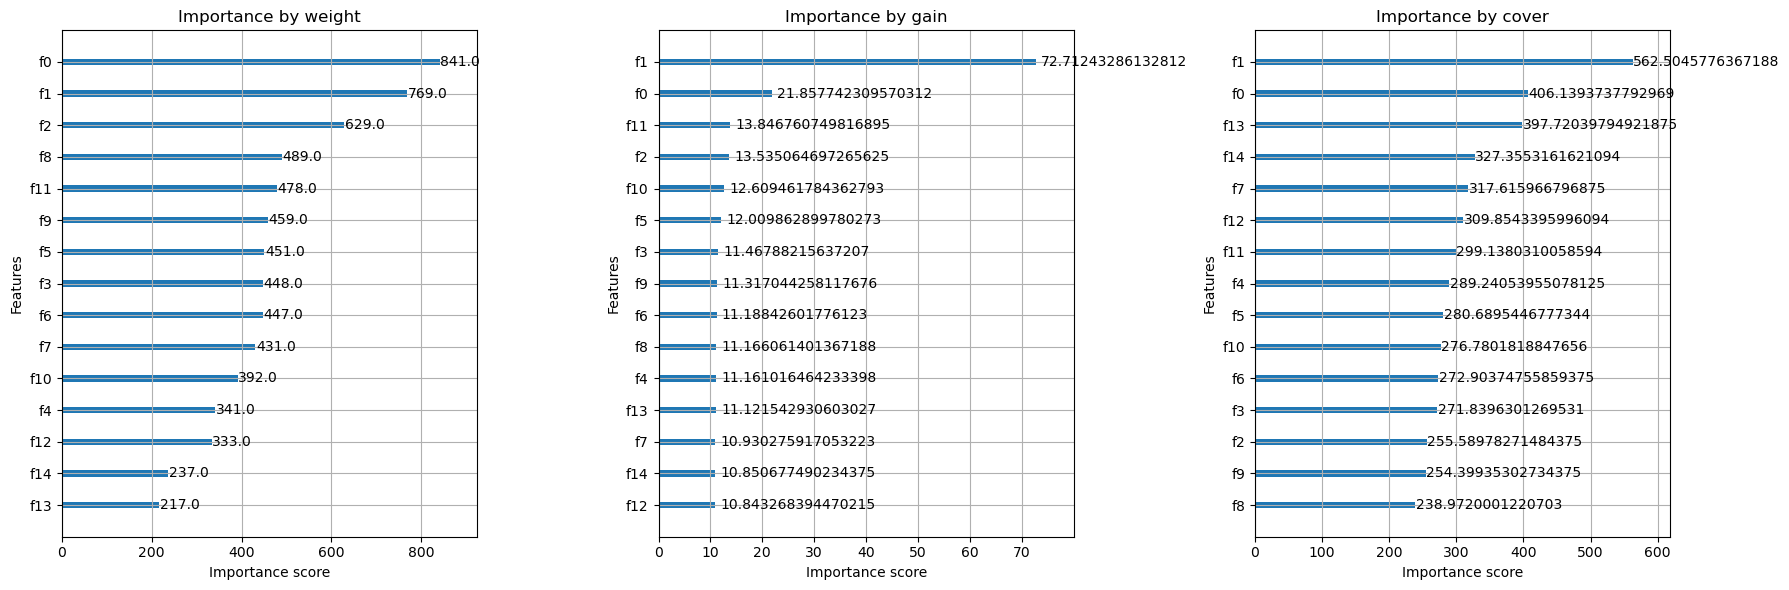

In [15]:

xgb_model = grid.best_estimator_.named_steps['classifier']
feature_names = ff_df.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, importance_type in zip(axes, ['weight', 'gain', 'cover']):
    xgb.plot_importance(
        xgb_model,
        importance_type=importance_type,
        ax=ax,
        title=f'Importance by {importance_type}',
    )

plt.tight_layout()
plt.show()

In [4]:
#SVM
from sklearn.svm import SVC

param_grid = {
    'svc__C': [.001,.01,.1,1,10,100],
    'svc__gamma': [.001,.01,.1,1,10,100]

}

pipe = make_pipeline(
    StandardScaler(),
    SVC(probability=True, class_weight='balanced')
)

grid = GridSearchCV(pipe, param_grid=param_grid, scoring='f1', cv=5)
grid.fit(X_train, y_train)

tuned = TunedThresholdClassifierCV(grid, scoring='f1', n_jobs=-1, cv='prefit')

y_pred = tuned.predict(X_test)

print(classification_report(y_test, y_pred))
print(roc_auc_score(y_test, tuned.predict_proba(X_test)[:, 1]))

RocCurveDisplay.from_estimator(tuned, X_test, y_test)
plt.show()


KeyboardInterrupt: 

In [ ]:
from sklearn.neural_network import MLPClassifier

nn_pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier()
)